[https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)

In [1]:
from ucimlrepo import fetch_ucirepo 

In [2]:
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
X = predict_students_dropout_and_academic_success.data.features 
y = predict_students_dropout_and_academic_success.data.targets

In [3]:
# metadata 
print(predict_students_dropout_and_academic_success.metadata.keys()) 

print('\n'+predict_students_dropout_and_academic_success.metadata['abstract']+'\n')
print('missing values:', predict_students_dropout_and_academic_success.metadata['has_missing_values']+'\n') 
print(predict_students_dropout_and_academic_success.metadata['additional_info']['recommended_data_splits']+'\n') 
print(predict_students_dropout_and_academic_success.metadata['additional_info']['instances_represent']+'\n') 
print(predict_students_dropout_and_academic_success.metadata['additional_info']['citation']+'\n')
print(predict_students_dropout_and_academic_success.metadata['creators']) 

dict_keys(['uci_id', 'name', 'repository_url', 'data_url', 'abstract', 'area', 'tasks', 'characteristics', 'num_instances', 'num_features', 'feature_types', 'demographics', 'target_col', 'index_col', 'has_missing_values', 'missing_values_symbol', 'year_of_dataset_creation', 'last_updated', 'dataset_doi', 'creators', 'intro_paper', 'additional_info'])

A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.
The dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. 
The data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification tas

---

### **Descripción**

Un conjunto de datos creado a partir de una institución de educación superior (integrado desde varias bases de datos independientes) que contiene información de estudiantes inscritos en distintas licenciaturas, como agronomía, diseño, educación, enfermería, periodismo, administración, trabajo social y tecnologías.

El dataset incluye información conocida en el momento de la inscripción del estudiante (trayectoria académica previa, datos demográficos y factores socioeconómicos), así como su desempeño académico al finalizar el primer y segundo semestre.

Los datos se utilizan para construir modelos de clasificación que predicen el abandono escolar (*dropout*) y el éxito académico de los estudiantes. El problema se plantea como una tarea de clasificación con tres categorías, en la cual existe un fuerte desbalance hacia una de las clases.

---

### **Autores**

* Valentim Realinho
* Mónica Vieira Martins
* Jorge Machado
* Luís Baptista

---

### **Cita**

M.V.Martins, D. Tolledo, J. Machado, L. M.T. Baptista, V.Realinho. (2021) "Early prediction of student’s performance in higher education: a case study" Trends and Applications in Information Systems and Technologies, vol.1, in Advances in Intelligent Systems and Computing series. Springer. DOI: 10.1007/978-3-030-72657-7_16

---

In [4]:
# variable information 
description = predict_students_dropout_and_academic_success.variables
display(description)

,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinan...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; a...,None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Ani...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education -...,None,no
6,Previous qualification (grade),Feature,Continuous,None,Grade of previous qualification (between 0 and...,None,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,None,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
9,Father's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no


# Bibliotecas

In [5]:
# Sistema
import os

# Análisis y manipulación de datos
import numpy as np
import pandas as pd

from scipy.stats import uniform

# Manejo de texto plano
import re
import emoji
import unicodedata

# Nube de palabras
from wordcloud import WordCloud, STOPWORDS

# Análisis de texto
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo de regresión logítica y Bayes
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Búsqueda de hiper-parámetros, train test, métricas
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer, mean_squared_error, mean_absolute_error
from sklearn.svm import LinearSVC, SVR

# Guardar modelo y pipeline
import pickle
from sklearn.pipeline import make_pipeline

#Graficas

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pandas.plotting import andrews_curves

# Funciones

In [6]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [7]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2)

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#de3163"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#31deac", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values,textinfo='label+value+percent',
                    marker=dict(colors=["#de3163", "#31deac"])
                                )
                    ]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Inferno'))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

# EDA

## Dataset

In [8]:
students = pd.concat([X, y], axis=1)

In [9]:
students.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [10]:
students.shape

(4424, 37)

In [11]:
is_na_df(students)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,163688,0.0,1.0


## Definición de variables

In [12]:
var_cat = students.select_dtypes('object').columns.tolist() + [x for x in students.columns if students[x].unique().__len__() < 10]

In [13]:
var_num = [x for x in students.columns if x not in var_cat]

## Distribución de variables

In [14]:
analisis_students = analyze(students, var_num, var_cat)

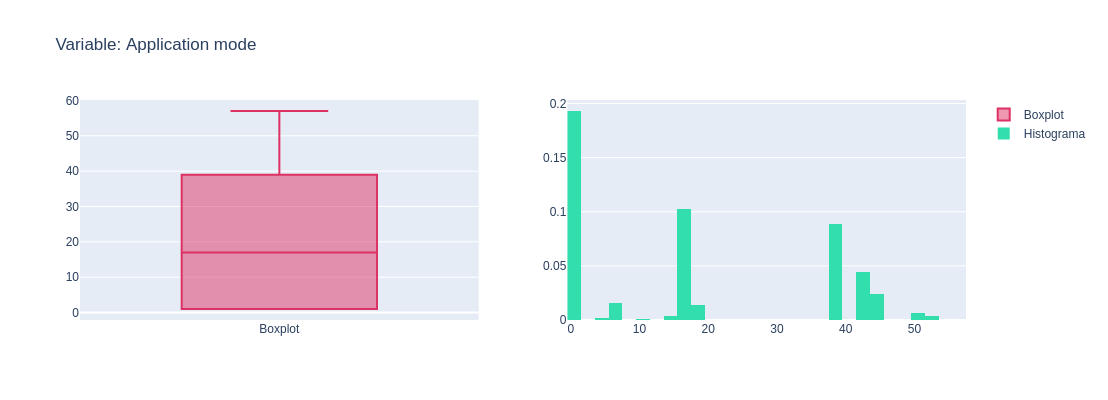

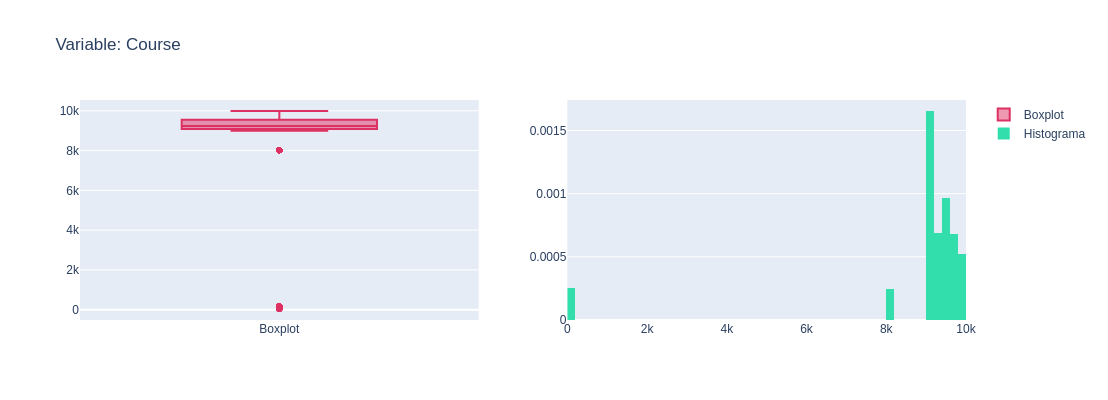

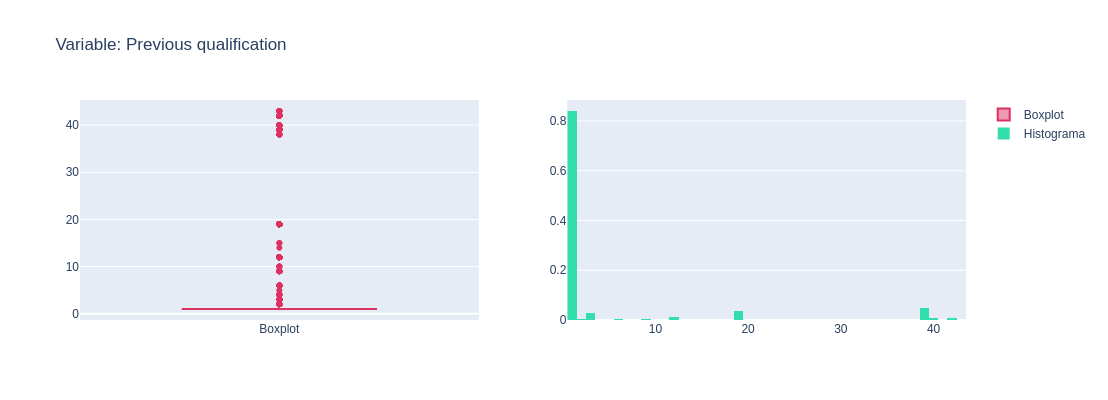

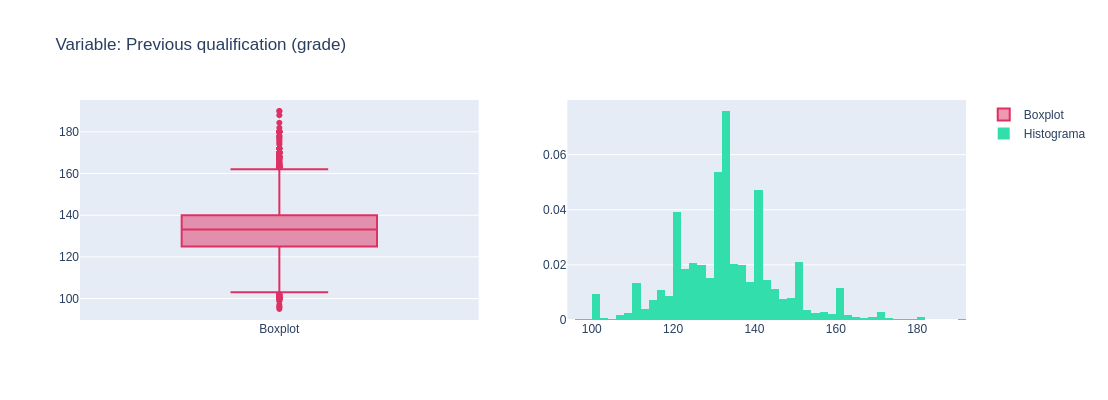

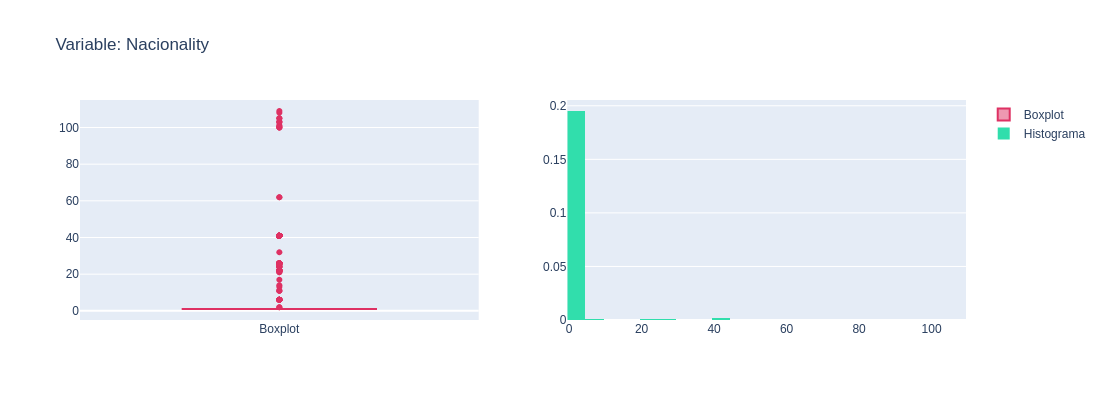

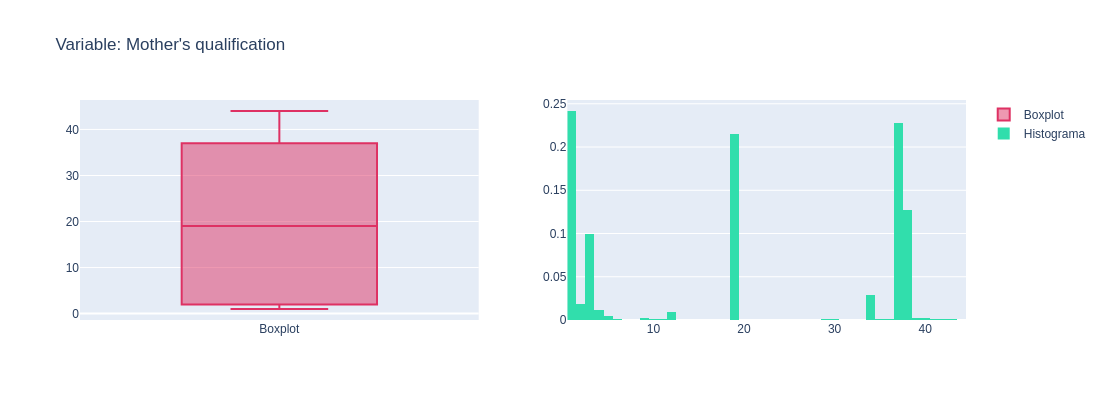

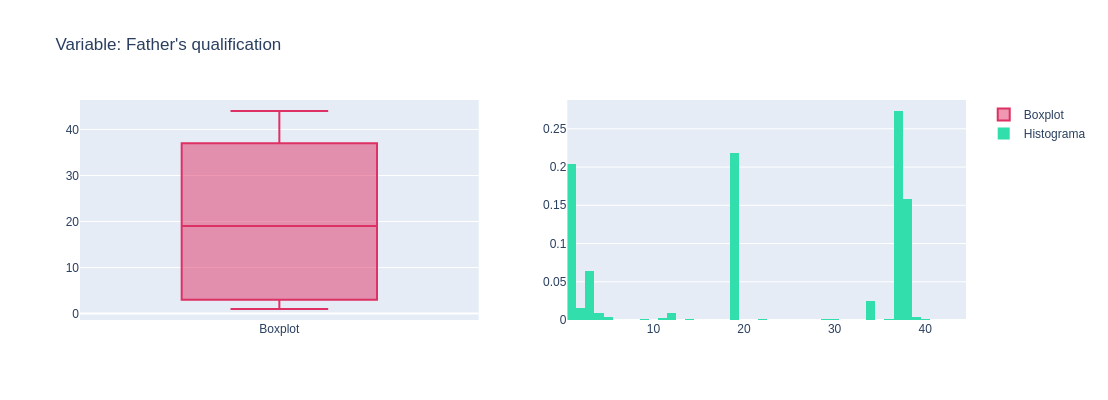

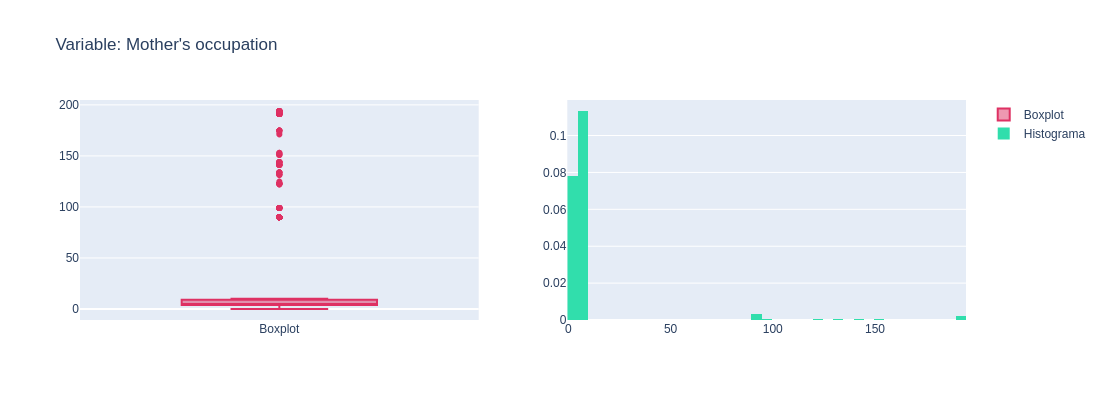

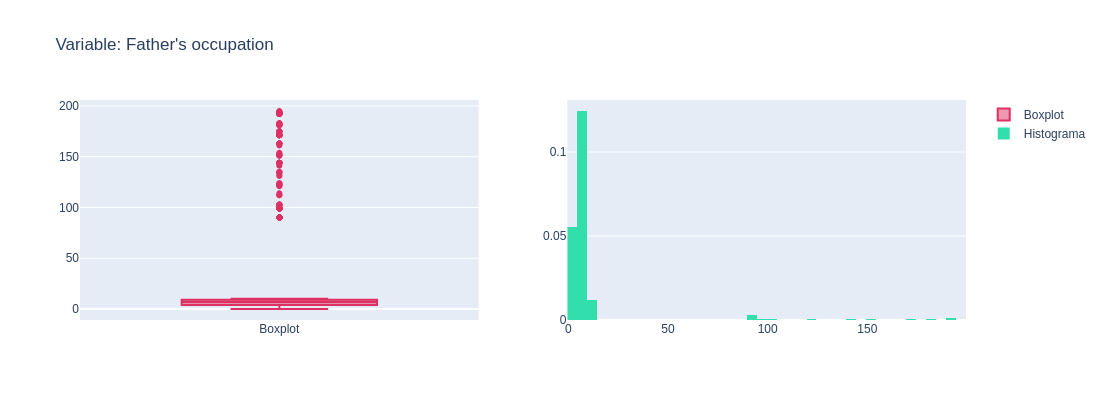

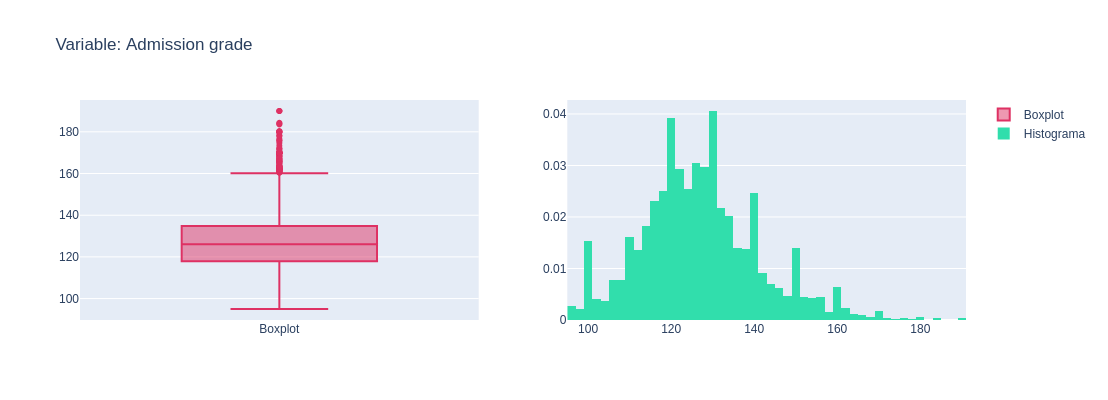

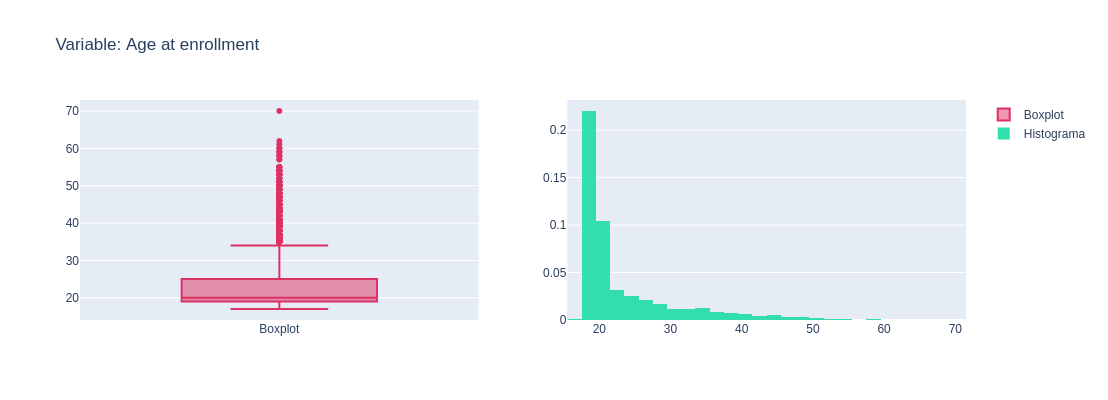

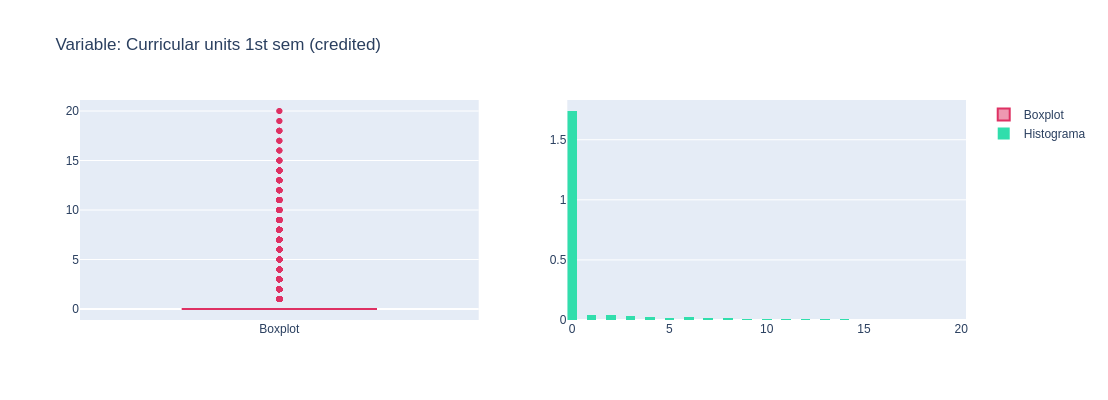

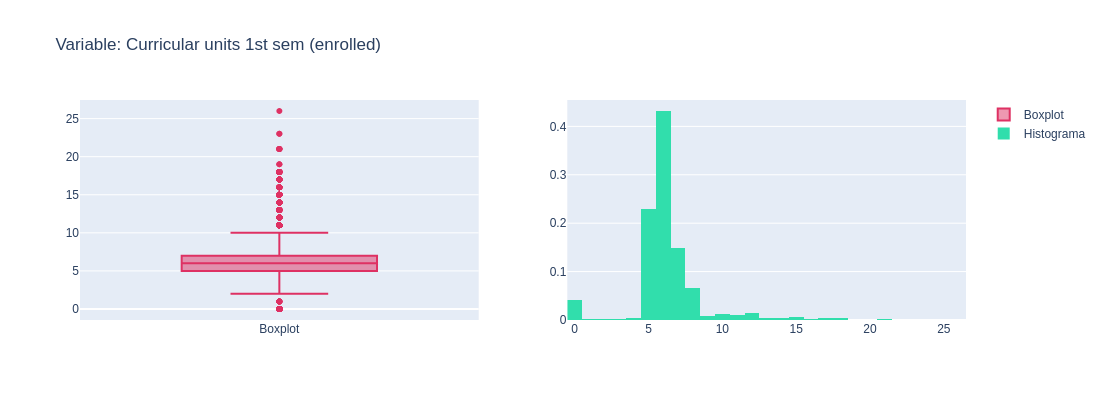

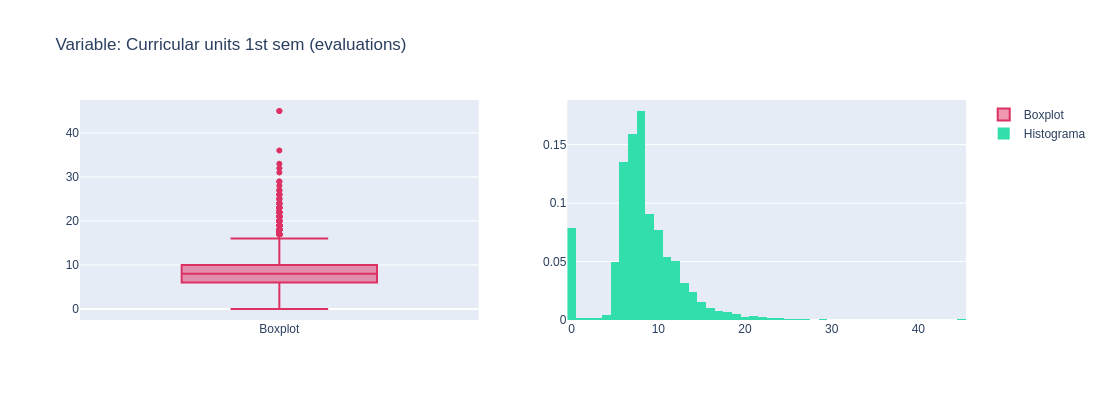

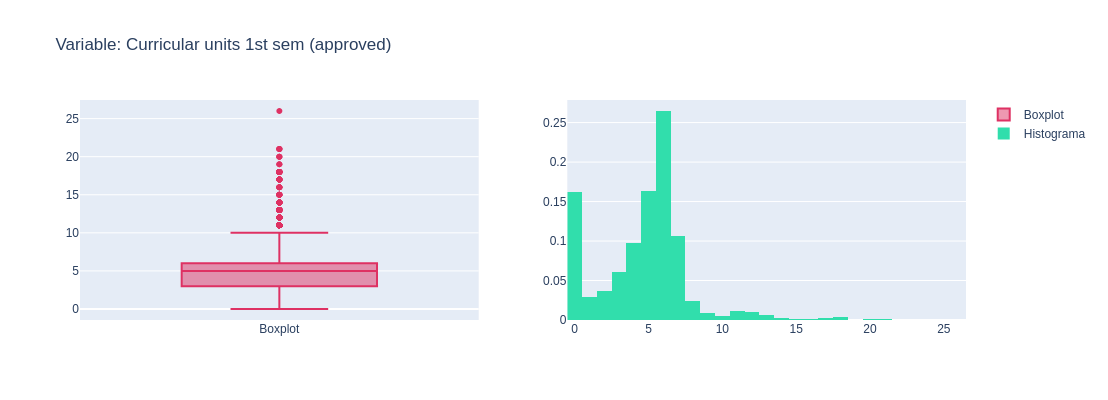

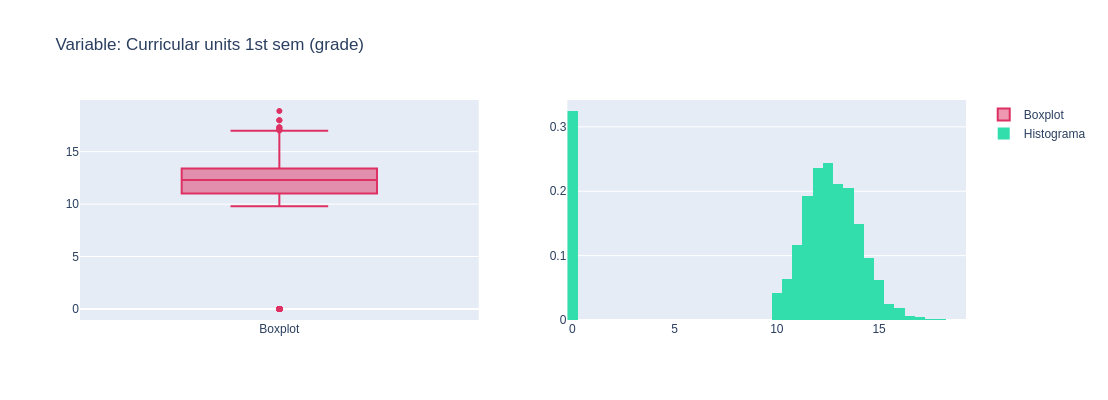

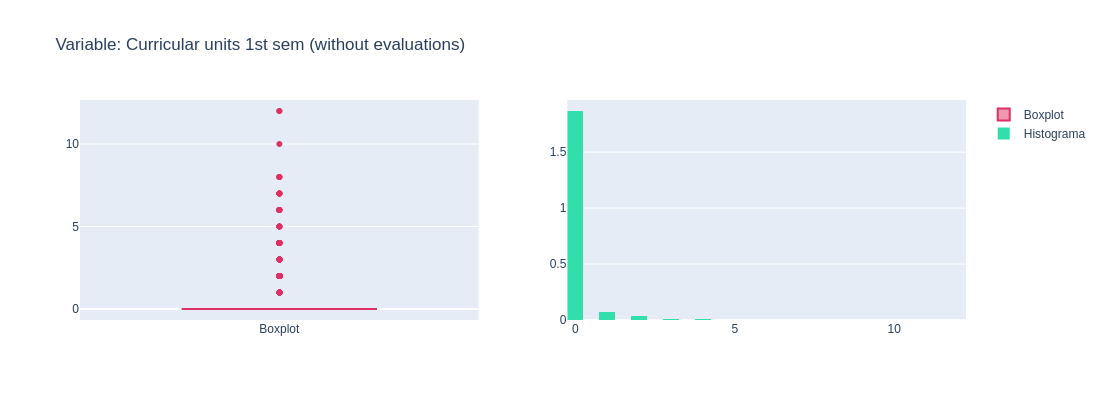

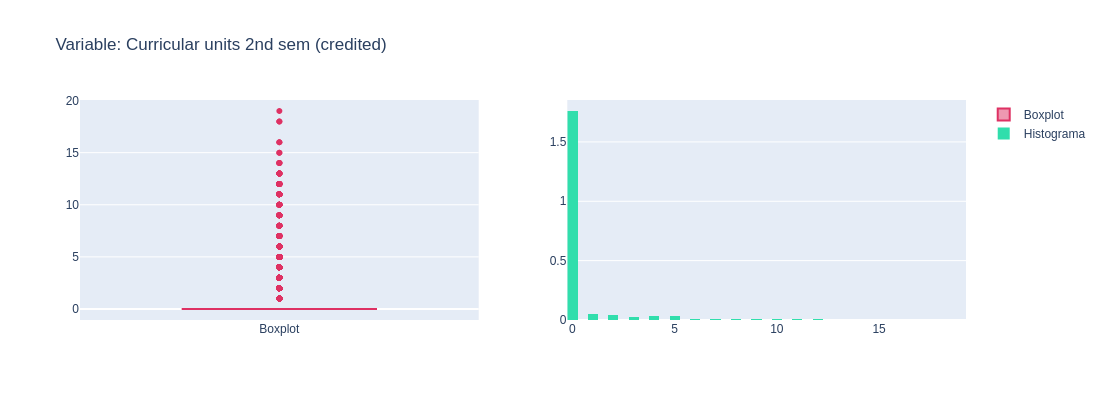

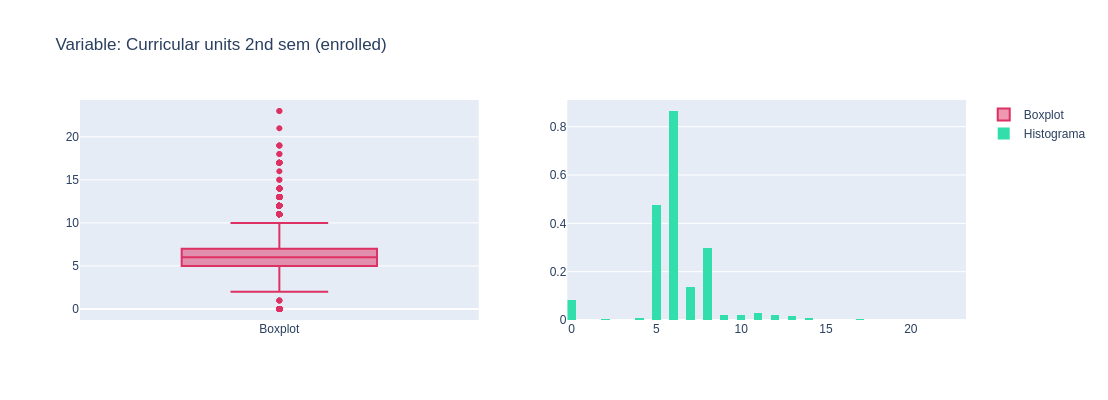

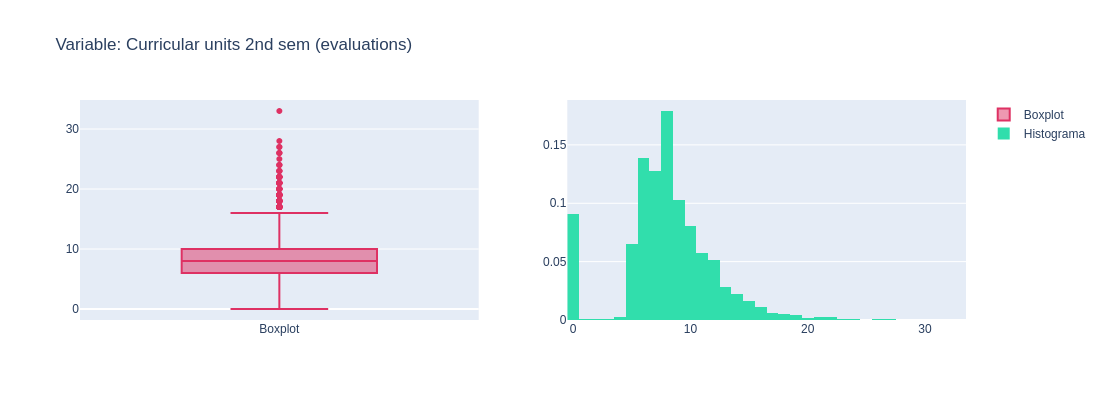

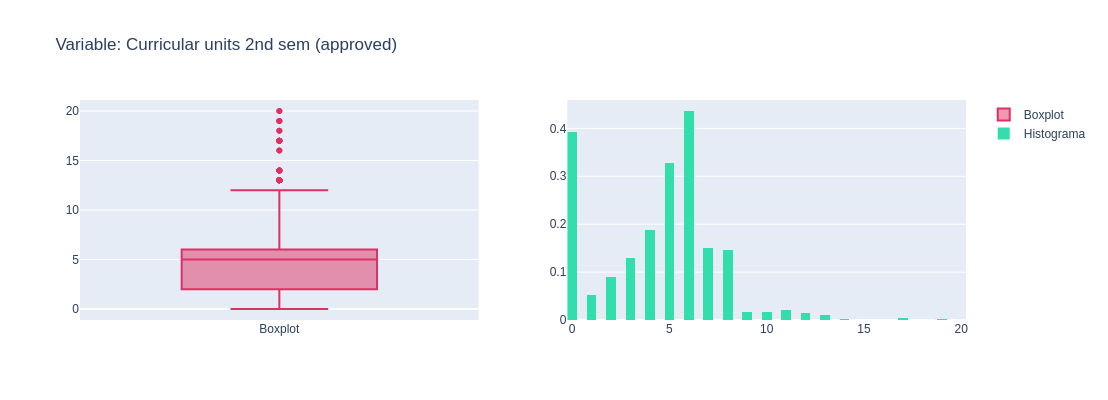

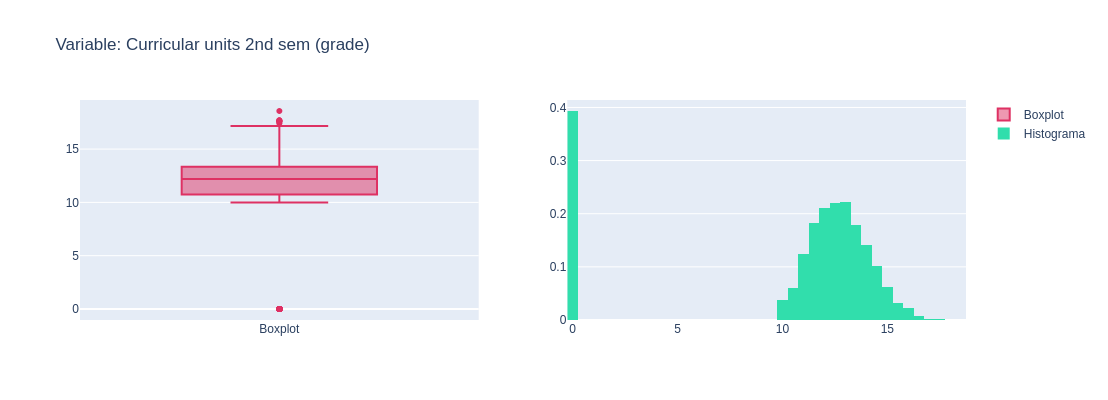

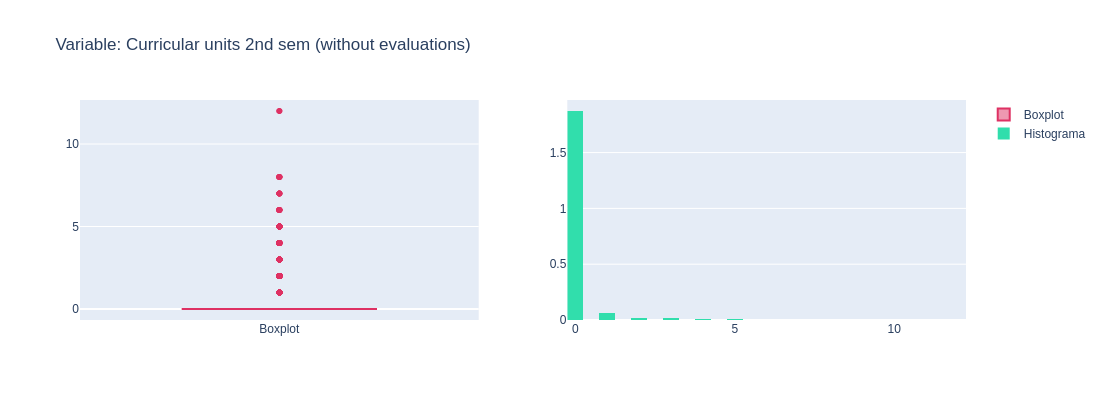

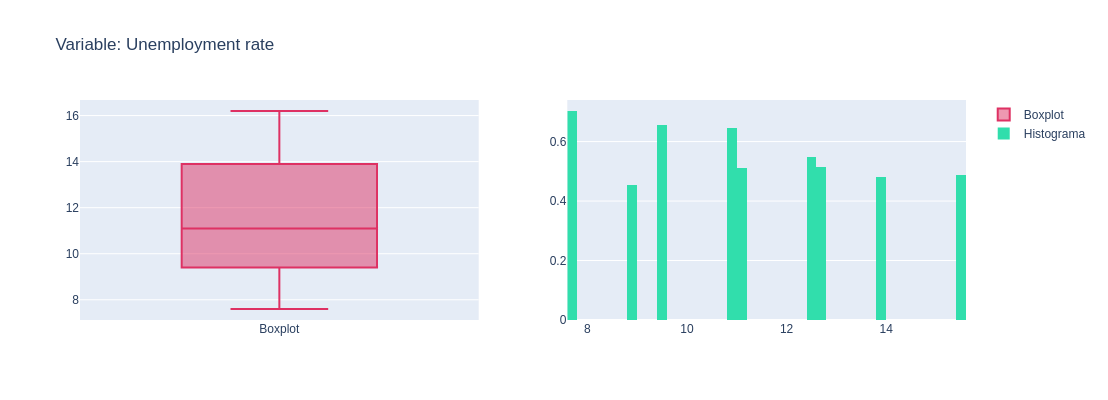

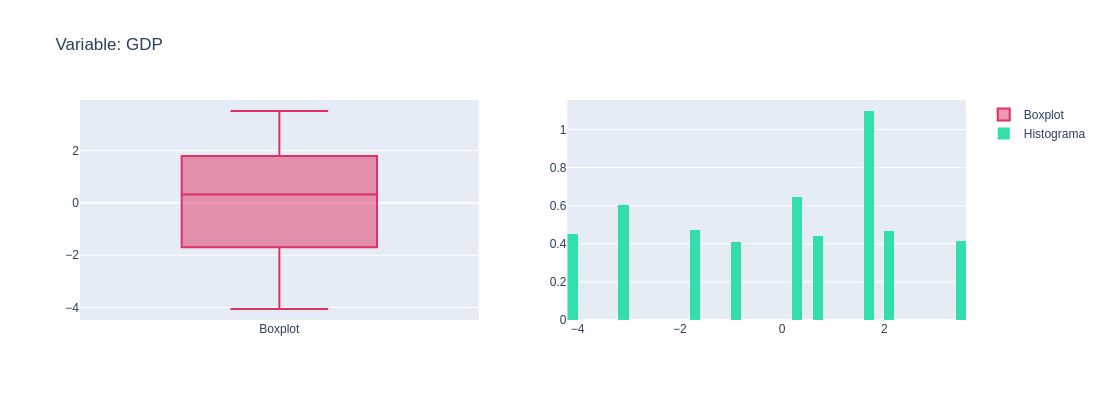

In [15]:
analisis_students.plot_num()

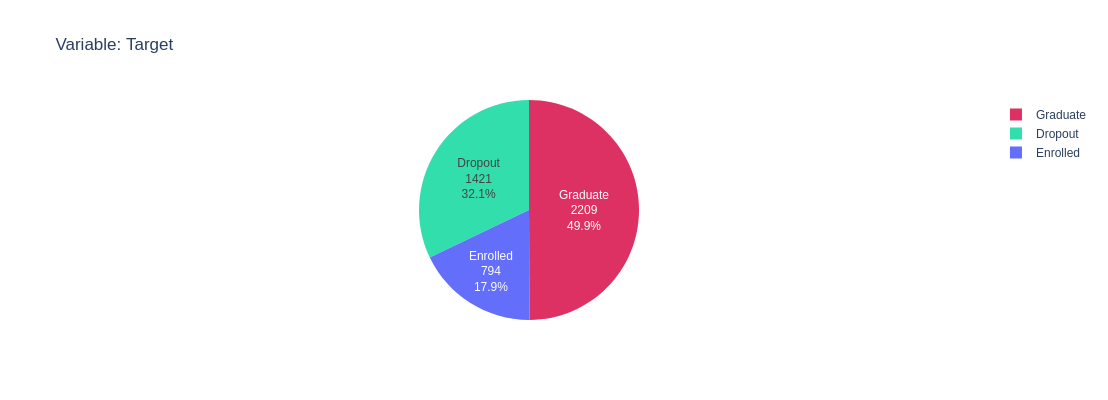

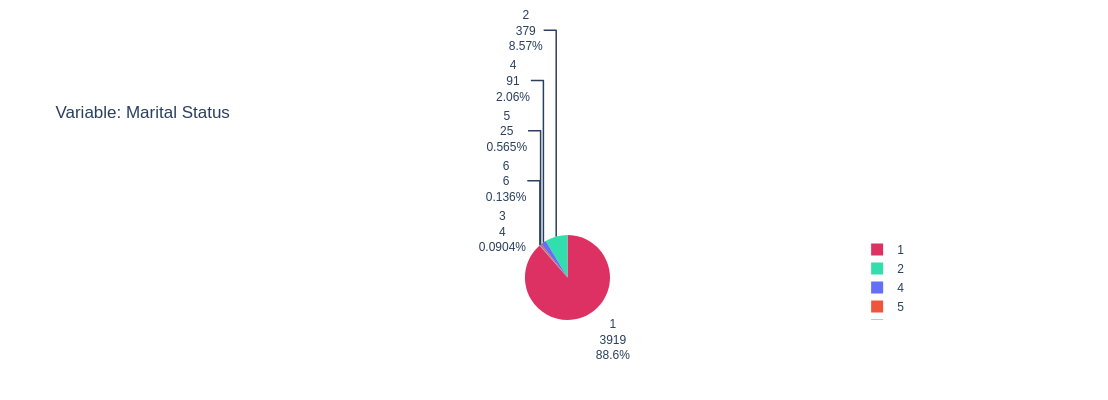

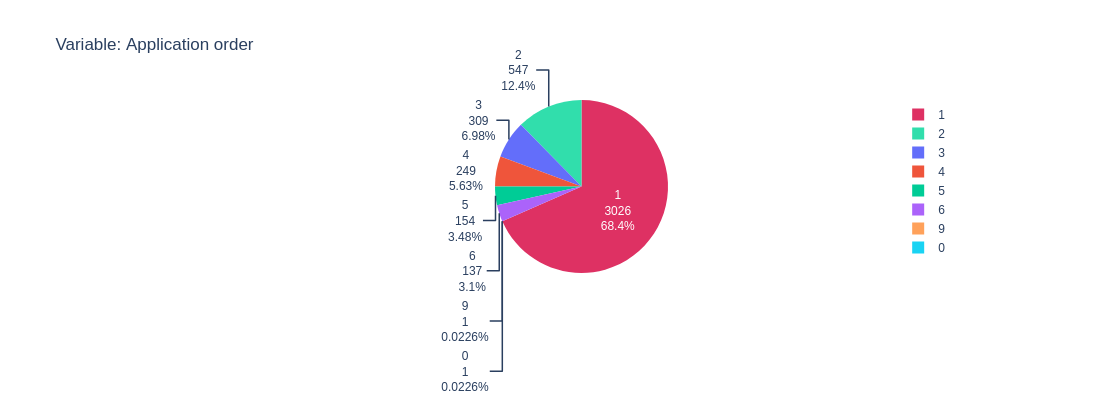

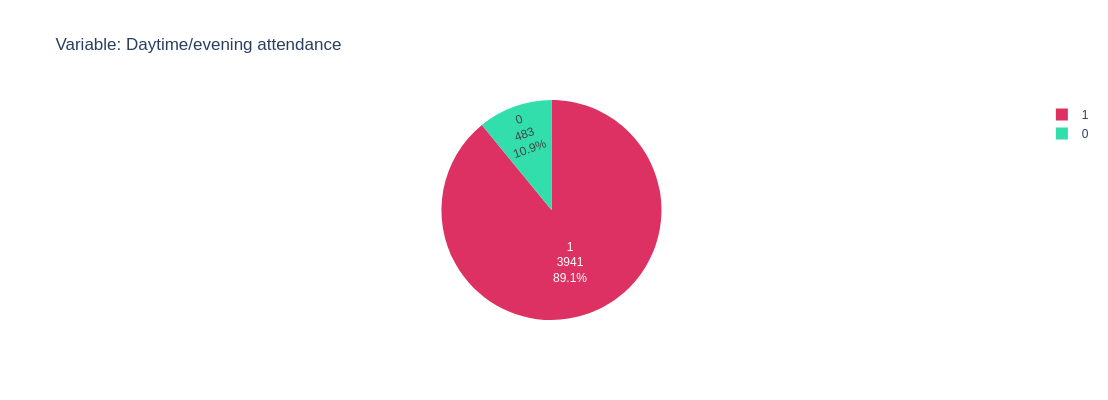

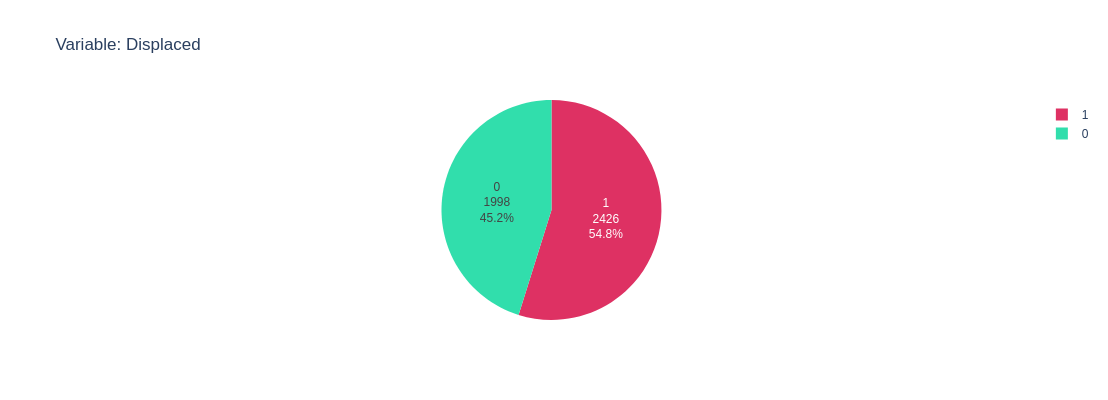

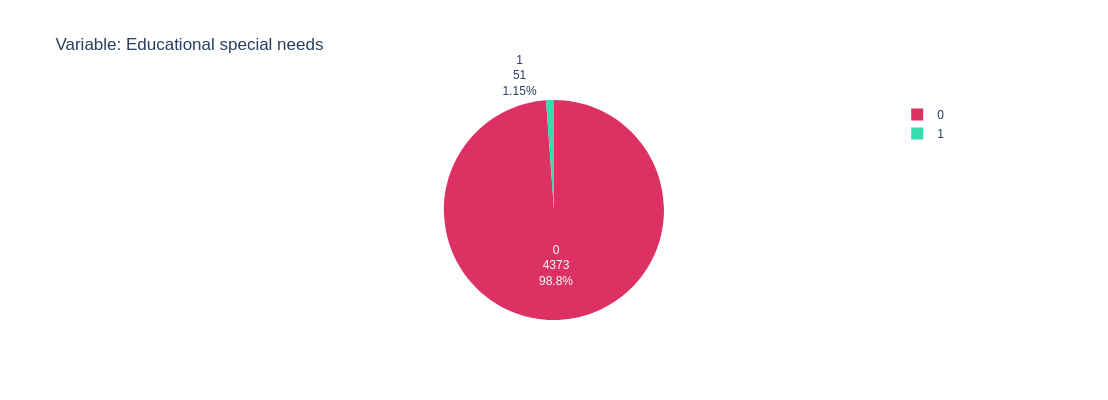

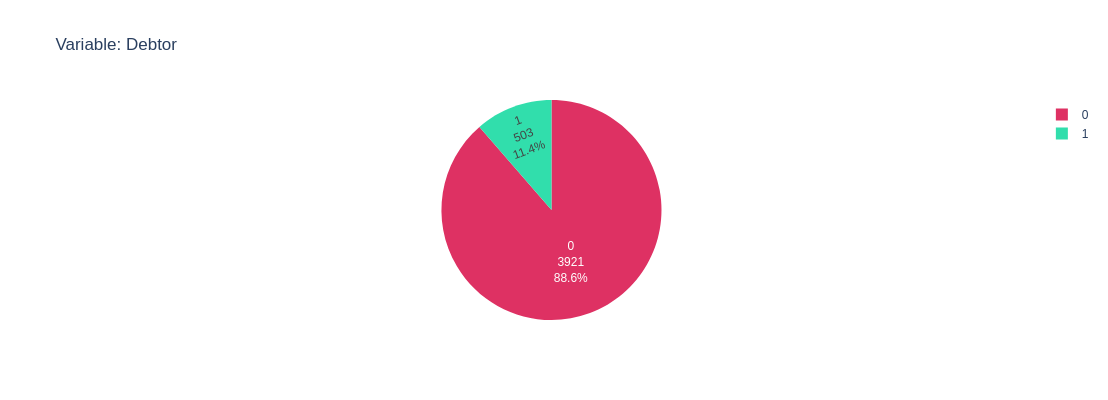

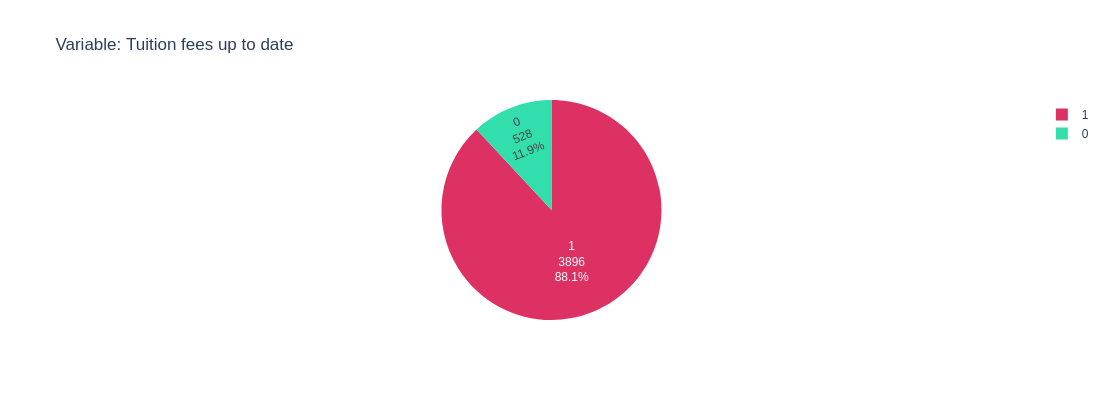

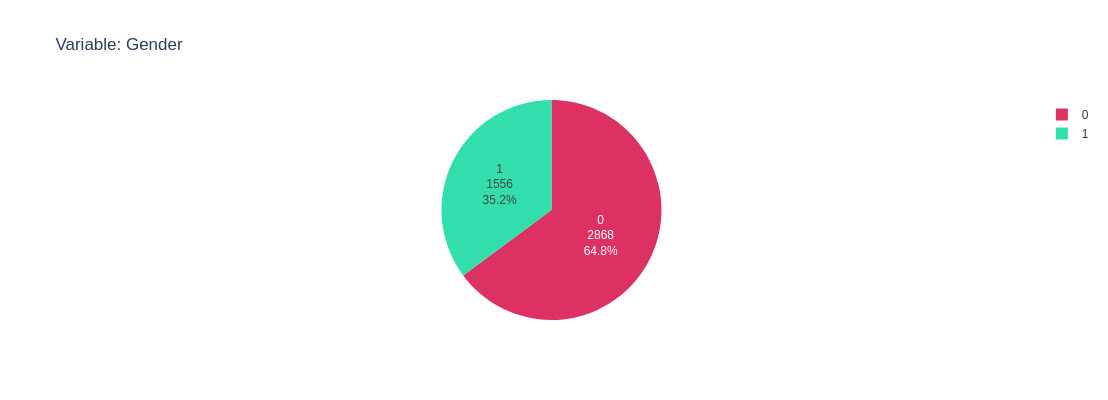

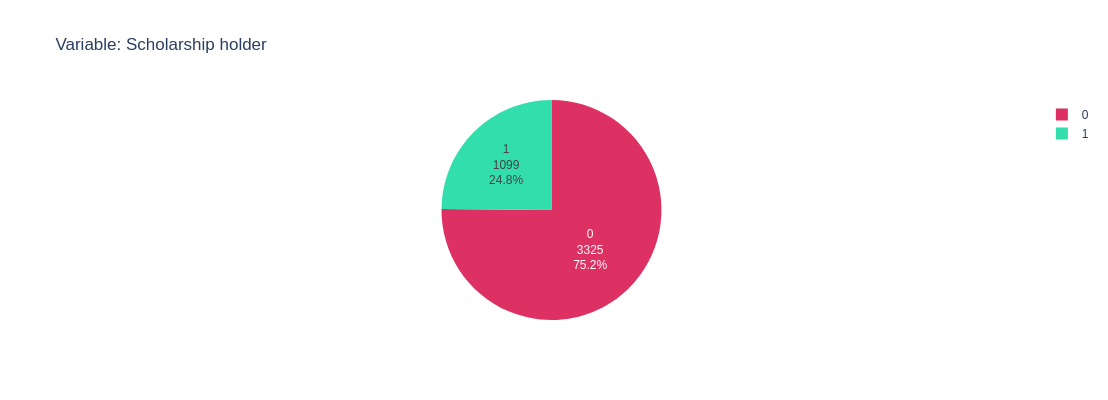

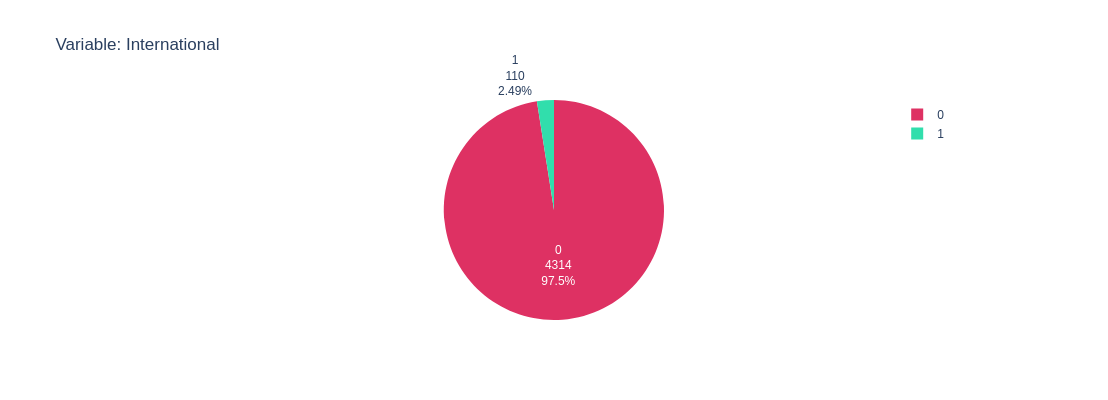

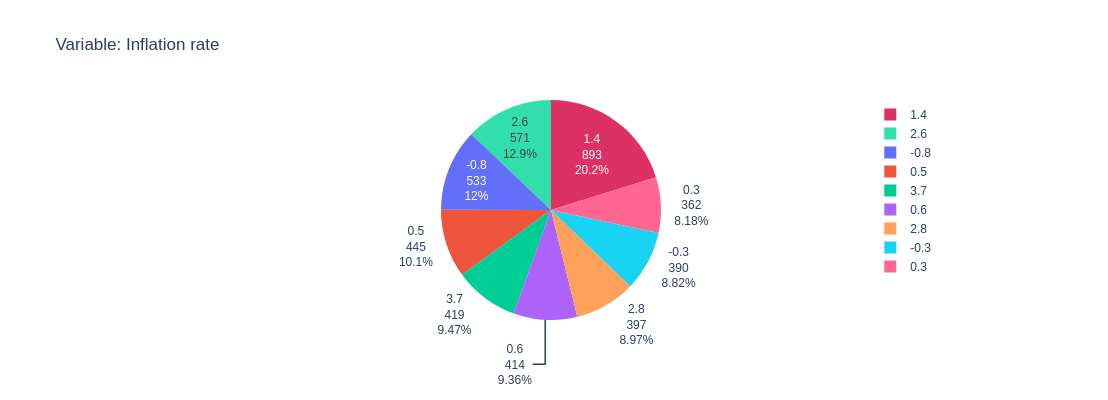

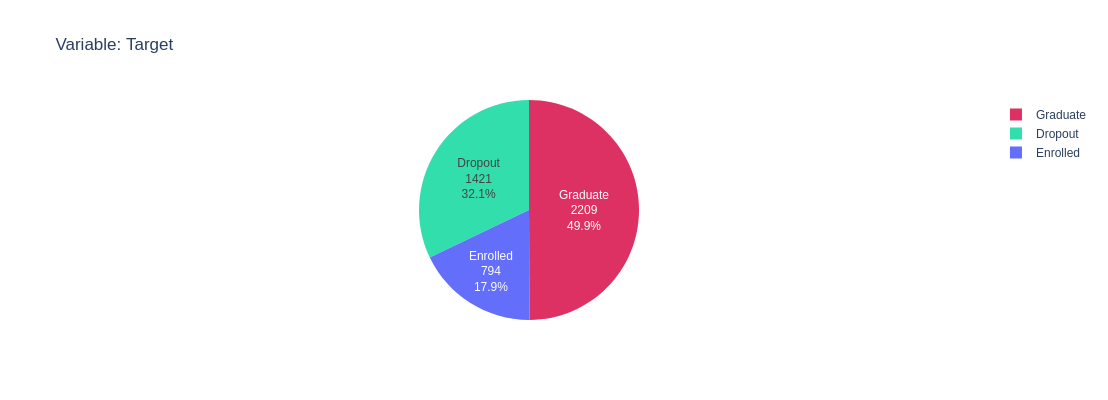

In [16]:
analisis_students.plot_cat()

Variables categóricas desbalanceadas
* Daytime / evening attendance
* Educational special needs
* Debtor (could go)
* Tuition fees up to date (could go)
* International

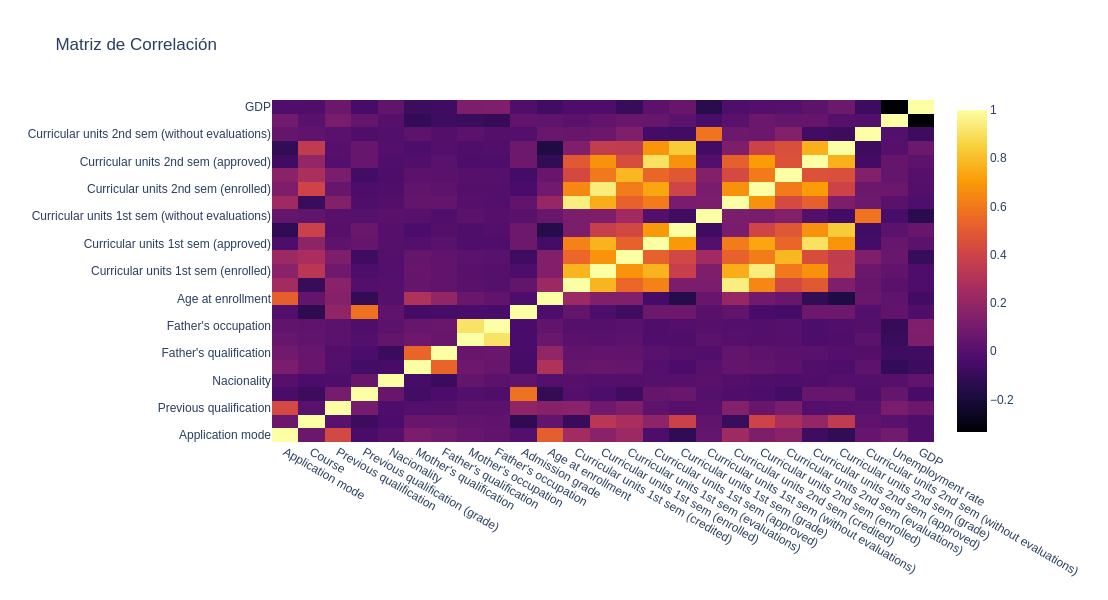

In [19]:
analisis_students.corr_matrix()

In [20]:
def locf(field: str):
    global description
    return description.loc[description['name'] == field]['description'].iloc[0]

In [21]:
locf('Course')

'33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance) 9003 - Agronomy 9070 - Communication Design 9085 - Veterinary Nursing 9119 - Informatics Engineering 9130 - Equinculture 9147 - Management 9238 - Social Service 9254 - Tourism 9500 - Nursing 9556 - Oral Hygiene 9670 - Advertising and Marketing Management 9773 - Journalism and Communication 9853 - Basic Education 9991 - Management (evening attendance)'

Jajaja sí, esa regex se ve medio monstruo al principio 😅
Vamos por partes, porque **cada pedacito hace algo muy específico**.

La expresión que usamos en `re.split` fue:

```python
r'(?<!\d)(?=\d+\s*-\s*)'
```

La idea general:
👉 *“Corta el texto en cualquier posición donde COMIENCE un número seguido de `-`, siempre y cuando antes no haya otro dígito.”*

Ahora sí, línea por línea:

---

### 1. `(?<!\d)` → *negative lookbehind*

* `(?<! … )` se llama **lookbehind negativo**.
* Traducción: *“en esta posición, asegúrate de que justo antes NO haya algo que cumpla …”*.
* En nuestro caso: `(?<!\d)` significa:

> “La posición donde vas a cortar **no puede estar precedida por un dígito** (`\d`).”

¿Para qué sirve?
Para evitar partir números en medio.
Sin esto, en `33 - Biofuel…` la regex vería:

* posición antes del primer `3` ✅
* posición antes del segundo `3` ✅

Y te cortaría en dos: `3` y `3 - Biofuel…` (que era justo el problema anterior).

Con `(?<!\d)` obligamos a que justo antes haya **cualquier cosa menos un dígito** (inicio de cadena, espacio, letra, etc.).

---

### 2. `(?=\d+\s*-\s*)` → *positive lookahead*

* `(?= … )` es un **lookahead positivo**.
* Traducción: *“a partir de esta posición, debe venir algo que cumpla …, pero no lo consumas, solo míralo.”*

Lo que va dentro:

#### a) `\d+`

* `\d` = dígito (0–9).
* `+` = “uno o más”.
* `\d+` = “uno o más dígitos seguidos” → el código de la carrera: `33`, `171`, `8014`, etc.

#### b) `\s*`

* `\s` = cualquier espacio en blanco (espacio, tab, salto de línea).
* `*` = “cero o más”.
* `\s*` = “puede haber espacios o no”.

Lo usamos para ser **tolerantes** con el formato:
`33 -`, `33-`, `33    -`, etc.

#### c) `-`

* El guion literal que separa: `código - nombre`.

#### d) otro `\s*`

* De nuevo, espacios opcionales después del guion:

  * `33 - Biofuel`
  * `33 -Biofuel`
  * `33- Biofuel`

Entonces todo el bloque:

```regex
(?=\d+\s*-\s*)
```

significa:

> “a partir de aquí debe venir: uno o más dígitos, luego opcionalmente espacios, luego un guion, luego opcionalmente espacios”.

Y como es **lookahead**, *no se incluye* en el resultado de `split`; solo marca la posición de corte.

---

### 3. ¿Cómo encajan juntos?

Completa:

```regex
(?<!\d)(?=\d+\s*-\s*)
```

Leído en español:

> “Corta en cualquier posición donde:
>
> * justo antes no haya un dígito,
> * y justo después comience un bloque `<número> -` (con espacios opcionales).”

Por eso `re.split` te regresa cada elemento empezando exactamente en el código:

```text
33 - Biofuel Production Technologies
171 - Animation and Multimedia Design
8014 - Social Service (evening attendance)
...
```

---

### 4. La segunda regex: `r'\s*-\s*'`

Esta es la sencilla que usaste para separar código y nombre:

```python
re.split(r'\s*-\s*', x, maxsplit=1)
```

* `\s*` → espacios opcionales antes del guion.
* `-`   → el guion literal.
* `\s*` → espacios opcionales después del guion.
* `maxsplit=1` → solo partir una vez (en el primer guion).

Resultado:

```python
'33 - Biofuel Production Technologies'
# → ['33', 'Biofuel Production Technologies']
```

---

Si quieres, en otra celda podemos jugar con varios ejemplos y ver **qué parte matchea exacto en cada caso**, para que le agarres más confianza a los lookahead/lookbehind, que son de lo más útil en regex 💪


In [22]:
def new_dic(field: str):
    text = locf(field)   # tu función que devuelve la descripción

    # 1) separar cada bloque "código – texto"
    items = re.split(r'(?<!\d)(?=\d+\s*[-–]\s*)', text)
    items = [i.strip() for i in items if i.strip()]

    # 2) separar código y texto dentro de cada bloque
    pares = [re.split(r'\s*[-–]\s*', x, maxsplit=1) for x in items]

    return dict(pares)

In [101]:
def plot_bar(field: str, dic: dict, y: bool = None, x: bool = None, normalize: bool = False):

    global students
    
    values = students[field].value_counts(normalize)
    values.index = values.index.astype(str).map(dic)

    display(pd.DataFrame(pd.Series({x: '{:.2%}'.format(y / students.shape[0]) for x, y in values.items()})).T)
    print()
    
    plt.figure(figsize=(12,4))
    
    if x:
        sns.barplot(x=values.index, y=values.values)

    if y:
        sns.barplot(x=values.values, y=values.index)
        
    plt.xticks(rotation=60)
    plt.show()

In [108]:
courses = new_dic('Course')

,Nursing,Management,Social Service,Veterinary Nursing,Journalism and Communication,Advertising and Marketing Management,Management (evening attendance),Tourism,Communication Design,Animation and Multimedia Design,Social Service (evening attendance),Agronomy,Basic Education,Informatics Engineering,Equinculture,Oral Hygiene,Biofuel Production Technologies
0,17.31%,8.59%,8.02%,7.62%,7.48%,6.06%,6.06%,5.70%,5.11%,4.86%,4.86%,4.75%,4.34%,3.84%,3.19%,1.94%,0.27%


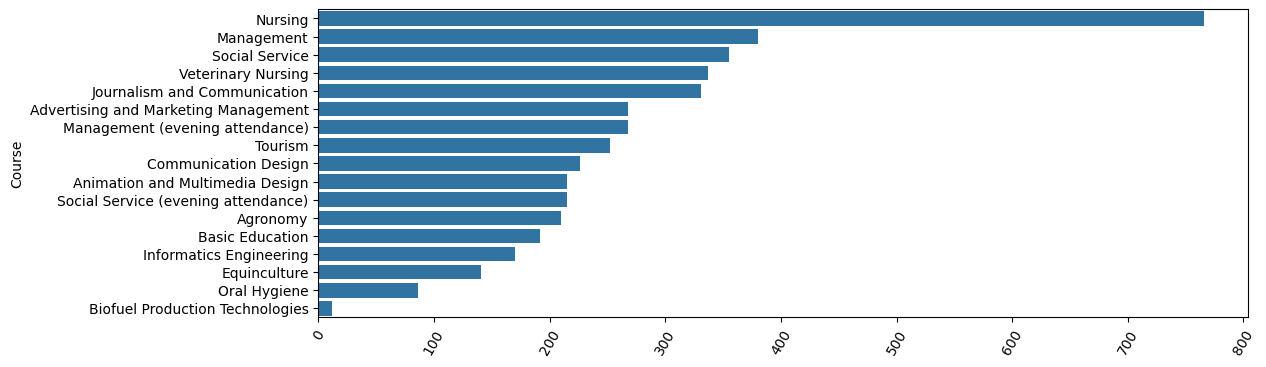

In [114]:
plot_bar('Course', courses, y=True)

> **Hay más estudiantes de enfermería.**

In [110]:
mar_status = new_dic('Marital Status')

,single,married,divorced,facto union,legally separated,widower
0,88.58%,8.57%,2.06%,0.57%,0.14%,0.09%


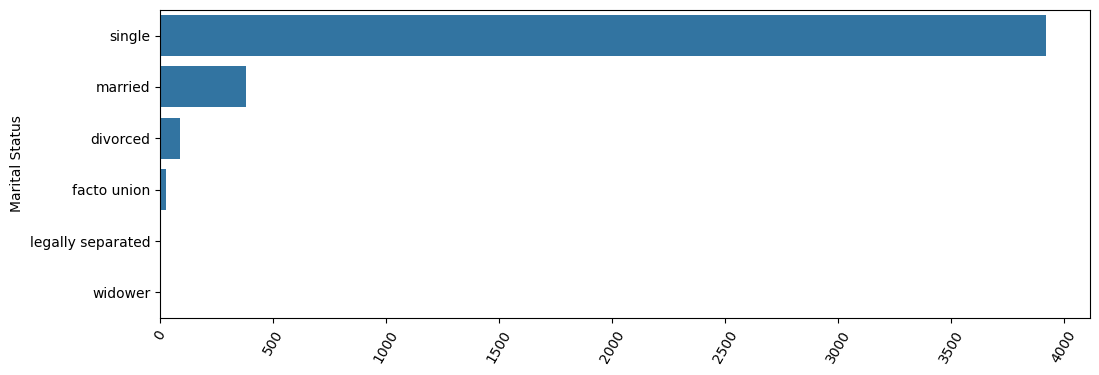

In [113]:
plot_bar('Marital Status', mar_status, y=True)

> **La mayoría de los alumnos son solteros.**

In [107]:
gender = new_dic('Gender')

,female,male
0,64.83%,35.17%


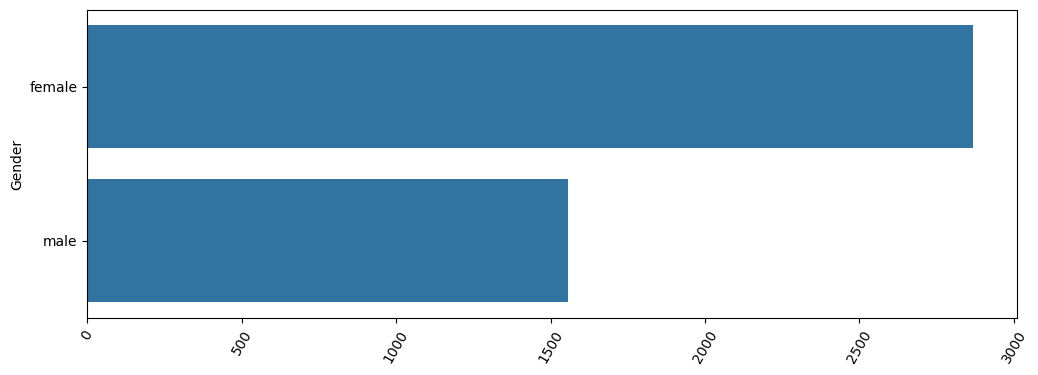

In [102]:
plot_bar('Gender', gender, y=True)

> **Hay más mujeres que hombres.**

In [106]:
gender = new_dic('Nacionality')

,Portuguese,Brazilian,Santomean,Cape Verdean,Spanish,Guinean,Moldova (Republic of),Italian,Ukrainian,Angolan,...,Romanian,Mozambican,German,Russian,Turkish,Dutch,Colombian,Cuban,English,Lithuanian
0,97.51%,0.86%,0.32%,0.29%,0.29%,0.11%,0.07%,0.07%,0.07%,0.05%,...,0.05%,0.05%,0.05%,0.05%,0.02%,0.02%,0.02%,0.02%,0.02%,0.02%


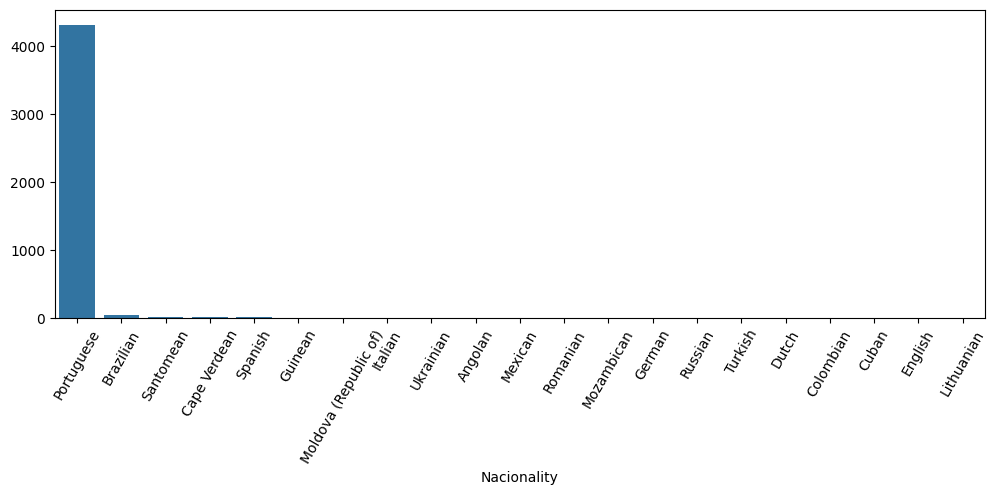

In [103]:
plot_bar('Nacionality', nacionality, x=True)

> **La mayoría de alumnos son portugueses.**

In [127]:
app_mode = new_dic('Application mode')

,1st phase - general contingent,2nd phase - general contingent,Over 23 years old,Change of course,Technological specialization diploma holders,Holders of other higher courses,3rd phase - general contingent,Transfer,Change of institution/course,1st phase - special contingent (Madeira Island),Short cycle diploma holders,International student (bachelor),1st phase - special contingent (Azores Island),Ordinance No.,Ordinance No. 612/93,Change of institution/course (International)
0,38.61%,19.71%,17.74%,7.05%,4.81%,3.14%,2.80%,1.74%,1.33%,0.86%,0.79%,0.68%,0.36%,0.02%,0.07%,0.02%


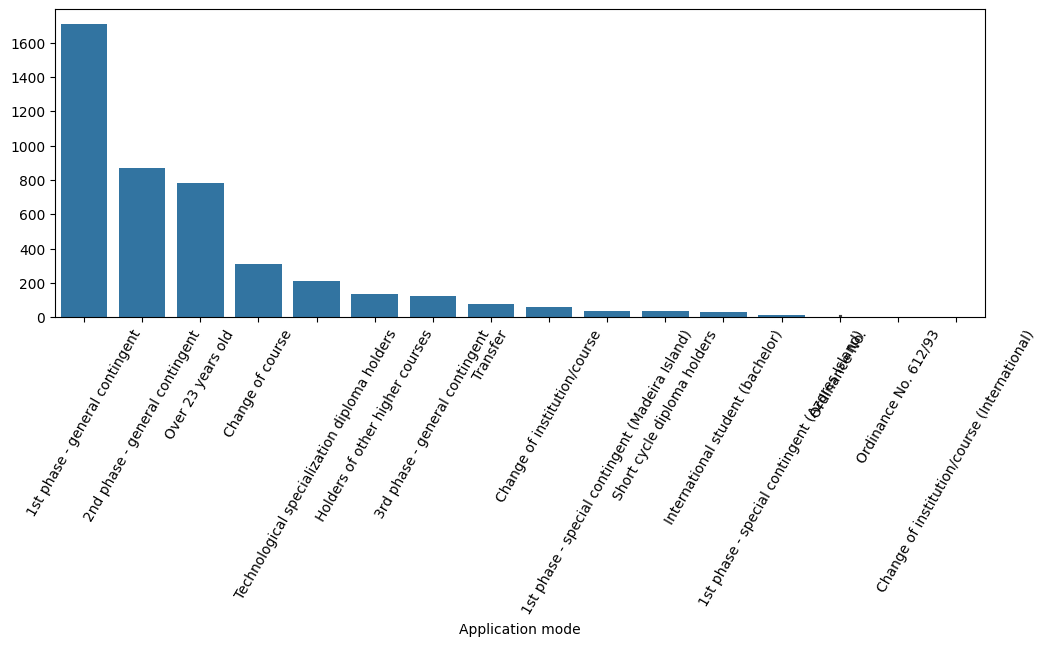

In [128]:
plot_bar('Application mode', app_mode, x=True)

,1,2,3,4,5,6,9,0
0,68.40%,12.36%,6.98%,5.63%,3.48%,3.10%,0.02%,0.02%


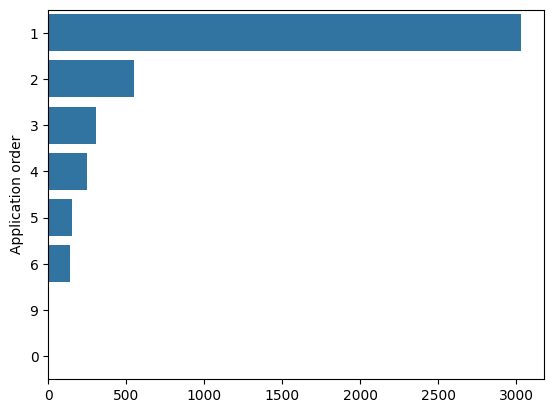

In [150]:
r = students['Application order'].value_counts()
r.index = r.index.astype(str)
# r.sort_index(inplace=True)

display(pd.DataFrame(pd.Series({x: '{:.2%}'.format(y / students.shape[0]) for x, y in r.items()})).T)
print()

sns.barplot(x=r.values, y=r.index)
plt.show()

In [115]:
locf('International')

'1 – yes 0 – no'

In [116]:
locf('Scholarship holder')

'1 – yes 0 – no'

In [117]:
locf('Tuition fees up to date')

'1 – yes 0 – no'

In [118]:
locf('Debtor')

'1 – yes 0 – no'

In [119]:
locf('Educational special needs')

'1 – yes 0 – no'

Variables categóricas desbalanceadas
* Daytime / evening attendance
* Educational special needs
* Debtor (could go)
* Tuition fees up to date (could go)
* International

In [126]:
cols = [
    'Debtor',
    'Daytime/evening attendance',
    'Educational special needs',
    'Tuition fees up to date',
    'International',
    'Application order'
]

mask = description['name'].isin(cols)

description.loc[mask, ['name', 'description']]

,name,description
2,Application order,Application order (between 0 - first choice; a...
4,Daytime/evening attendance,1 – daytime 0 - evening
14,Educational special needs,1 – yes 0 – no
15,Debtor,1 – yes 0 – no
16,Tuition fees up to date,1 – yes 0 – no
20,International,1 – yes 0 – no


## Descripción de Variables

In [107]:
description

,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinan...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; a...,None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Ani...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education -...,None,no
6,Previous qualification (grade),Feature,Continuous,None,Grade of previous qualification (between 0 and...,None,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,None,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
9,Father's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
